# Linear Regression

This is an updated version of Housing price prediction project. I added some new source codes to evaluate the accuracies and losses of Train and Validation process, then check again with Test data.

Epoch 1000 | Train Loss: 0.868884 | Val Loss: 0.855281
Epoch 2000 | Train Loss: 0.771352 | Val Loss: 0.744186
Epoch 3000 | Train Loss: 0.701716 | Val Loss: 0.667523
Epoch 4000 | Train Loss: 0.648462 | Val Loss: 0.615254
Epoch 5000 | Train Loss: 0.615601 | Val Loss: 0.580208
Epoch 6000 | Train Loss: 0.586614 | Val Loss: 0.557254
Epoch 7000 | Train Loss: 0.563884 | Val Loss: 0.542743
Epoch 8000 | Train Loss: 0.550437 | Val Loss: 0.534079
Epoch 9000 | Train Loss: 0.538945 | Val Loss: 0.529417
Epoch 10000 | Train Loss: 0.528977 | Val Loss: 0.527453

Difference of train_loss and val_loss: 0.0015
Average test_loss: 0.5001


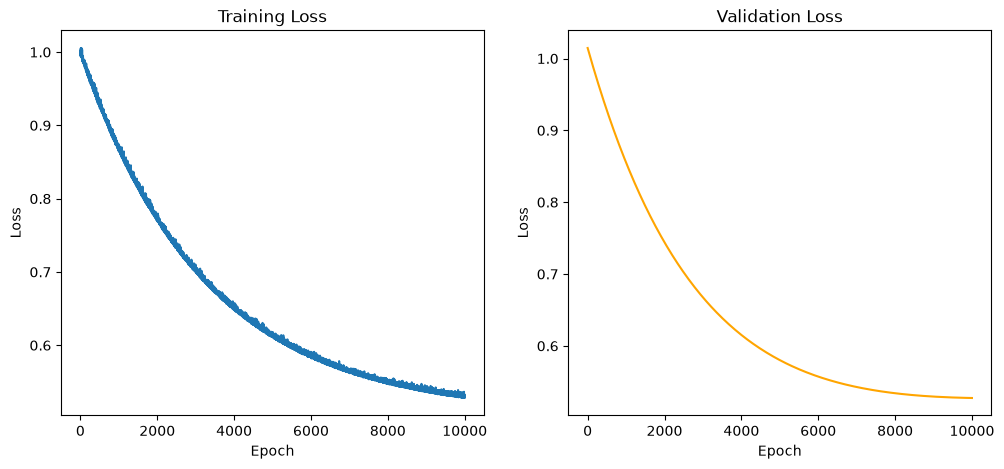

In [57]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
filename = f"{path}/{os.listdir(path)[0]}"

df = pd.read_csv(filename)

m = df.shape[0]

X = df[['area', 'bedrooms', 'bathrooms']].values
y = df['price'].values

X_bias = np.concatenate((np.ones((m, 1)), X), axis = 1)

# 2. Split Train, Validation, and Test
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_bias, y,
    test_size = val_size,
    random_state = random_state,
    shuffle = is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size = test_size,
    random_state = random_state,
    shuffle = is_shuffle
)

# 3. Scaling data
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

y_train = normalizer.fit_transform(y_train.reshape(-1, 1)).reshape(-1)
y_val = normalizer.transform(y_val.reshape(-1, 1)).reshape(-1)
y_test = normalizer.transform(y_test.reshape(-1, 1)).reshape(-1)

# 4. Important functions
def predict(theta, xi):
    return np.dot(xi, theta)

def compute_loss(yi, prediction):
    return (yi - prediction)**2

# 5. Mini-batch linear regression
def minibatch_linear_regression(X_train, y_train, X_val, y_val, batch_size = 64, 
                                   epochs = 10000, learning_rate = 1e-5):
    (m, n) = X_train.shape
    theta = np.zeros(n)
    
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        train_loss = 0

        indecies = np.random.permutation(m)
        X_shuffled = X_train[indecies]
        y_shuffled = y_train[indecies]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i: i + batch_size]
            y_batch = y_shuffled[i: i + batch_size]

            y_pred = predict(theta, X_batch)
            error = y_pred - y_batch
            theta = theta - (learning_rate / len(y_batch)) * (X_batch.T @ error)
            train_loss += np.mean(compute_loss(y_batch, y_pred))

        num_batches = (m + batch_size - 1) // batch_size
        avg_train_loss = train_loss / num_batches
        train_losses.append(avg_train_loss)
        
        y_val_pred = predict(theta, X_val)
        val_loss = compute_loss(y_val, y_val_pred)
        avg_val_loss = np.mean(val_loss)
        val_losses.append(avg_val_loss)

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1:4d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
        
    return theta, train_losses, val_losses

# 6. Print answer and plot diagram
theta, train_losses, val_losses = minibatch_linear_regression(X_train, y_train, X_val, y_val, 32, 10000, 1e-5)

train_loss = train_losses[-1]
val_loss = val_losses[-1]
print(f"\nDifference of train_loss and val_loss: {abs(train_loss - val_loss):.4f}")

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].plot(train_losses)
ax[0].set(xlabel = 'Epoch', ylabel = 'Loss')
ax[0].set_title('Training Loss')

ax[1].plot(val_losses, 'orange')
ax[1].set(xlabel = 'Epoch', ylabel = 'Loss')
ax[1].set_title('Validation Loss')

# 7. Evaluate:
test_loss = np.mean(compute_loss(y_test, predict(theta, X_test)))

print(f"Average test_loss: {test_loss:.4f}")